<a href="https://colab.research.google.com/github/JSEFERINO/Archivos-DOE-2026/blob/main/DBCAipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**José Caro Urueta**

In [ ]:
!pip install -q pingouin scipy

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 2. Reconstruir la base de datos del experimento
data = {
    'Operador': ['1', '1', '1', '1',
                 '2', '2', '2', '2',
                 '3', '3', '3', '3',
                 '4', '4', '4', '4'],
    'Metodo': ['A', 'B', 'C', 'D',
               'A', 'B', 'C', 'D',
               'A', 'B', 'C', 'D',
               'A', 'B', 'C', 'D'],
    'Tiempo': [6, 7, 10, 10,
               9, 10, 16, 13,
               7, 11, 11, 11,
               8, 8, 14, 9]
}

df = pd.DataFrame(data)

In [ ]:
# 3. Análisis de Varianza (ANOVA) para DBCA
modelo = ols('Tiempo ~ C(Metodo) + C(Operador)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=2)

print("--- 4 y 5. TABLA ANOVA ---")
print(tabla_anova)
print("\n" + "="*50 + "\n")

--- 4 y 5. TABLA ANOVA ---
             sum_sq   df      F    PR(>F)
C(Metodo)      61.5  3.0  10.25  0.002919
C(Operador)    28.5  3.0   4.75  0.029846
Residual       18.0  9.0    NaN       NaN




In [ ]:
# 4. Promedios por Método
medias = df.groupby('Metodo')['Tiempo'].agg(['sum', 'mean']).reset_index()
medias.columns = ['Metodo', 'Total (Y_i.)', 'Promedio']
print("--- 7. PROMEDIOS POR MÉTODO ---")
print(medias.to_string(index=False))
print("\n" + "="*50 + "\n")

# 5. Prueba HSD de Tukey (alfa = 0.05)
print("--- 10. PRUEBA HSD DE TUKEY ---")
tukey = pairwise_tukeyhsd(endog=df['Tiempo'], groups=df['Metodo'], alpha=0.05)
print(tukey)
print("\n" + "="*50 + "\n")

# 6. Prueba LSD de Fisher adaptada para DBCA (Cálculo exacto)
print("--- 11. PRUEBA LSD DE FISHER (DBCA) ---")
# Obtener los grados de libertad del error y el MSE (Mean Squared Error) de la tabla ANOVA
gl_error = int(tabla_anova.loc['Residual', 'df'])
mse = tabla_anova.loc['Residual', 'sum_sq'] / gl_error
n_bloques = 4  # número de operadores (b)

# Calcular la t crítica
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df=gl_error)

# Diferencia mínima significativa (LSD)
# Fórmula LSD = t_crit * sqrt(2 * MSE / b)
lsd_value = t_crit * (2 * mse / n_bloques)**0.5
print(f"LSD de Fisher (valor crítico) = {lsd_value:.3f}\n")

# Comparaciones por pares para LSD
import itertools
metodos = sorted(df['Metodo'].unique())
resultados_lsd = []

--- 7. PROMEDIOS POR MÉTODO ---
Metodo  Total (Y_i.)  Promedio
     A            30      7.50
     B            36      9.00
     C            51     12.75
     D            43     10.75


--- 10. PRUEBA HSD DE TUKEY ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B      1.5  0.709 -2.6325 5.6325  False
     A      C     5.25 0.0123  1.1175 9.3825   True
     A      D     3.25 0.1443 -0.8825 7.3825  False
     B      C     3.75 0.0799 -0.3825 7.8825  False
     B      D     1.75 0.6049 -2.3825 5.8825  False
     C      D     -2.0 0.5019 -6.1325 2.1325  False
---------------------------------------------------


--- 11. PRUEBA LSD DE FISHER (DBCA) ---
LSD de Fisher (valor crítico) = 2.262



In [ ]:
for m1, m2 in itertools.combinations(metodos, 2):
    media1 = medias.loc[medias['Metodo'] == m1, 'Promedio'].values[0]
    media2 = medias.loc[medias['Metodo'] == m2, 'Promedio'].values[0]
    dif = abs(media1 - media2)
    # Valor p aproximado usando la distribución t
    t_stat = dif / (2 * mse / n_bloques)**0.5
    p_val = 2 * (1 - stats.t.cdf(t_stat, df=gl_error))
    signif = "Sí" if dif > lsd_value else "No"

    resultados_lsd.append({
        'Comparación': f"{m1} - {m2}",
        'Dif. de medias': round(dif, 2),
        'p-ajustada (p-unc)': round(p_val, 4),
        '¿Signif.?': signif
    })

df_lsd = pd.DataFrame(resultados_lsd)
print(df_lsd.to_string(index=False))
print("\n" + "="*50 + "\n")

Comparación  Dif. de medias  p-ajustada (p-unc) ¿Signif.?
      A - B            1.50              0.1679        No
      A - C            5.25              0.0005        Sí
      A - D            3.25              0.0100        Sí
      B - C            3.75              0.0046        Sí
      B - D            1.75              0.1140        No
      C - D            2.00              0.0766        No




/tmp/ipykernel_1206/340210553.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Metodo', y='Tiempo', palette='Set2')


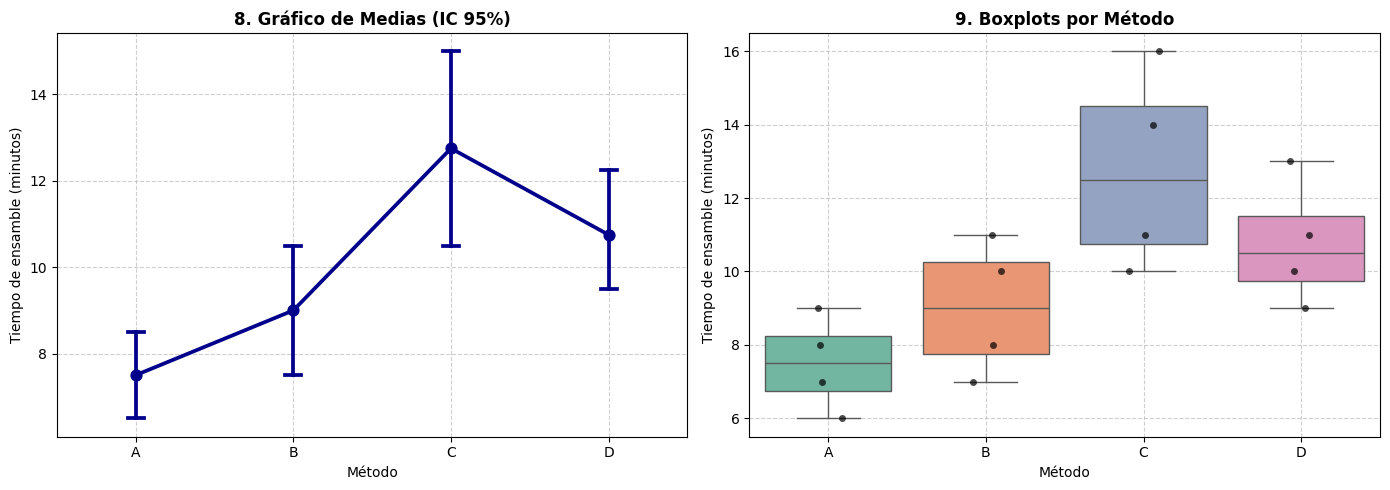

In [ ]:
# ==========================================
# 7. GENERACIÓN DE GRÁFICOS
# ==========================================
plt.figure(figsize=(14, 5))

# Gráfico 8: Gráfico de medias con intervalo de confianza del 95%
plt.subplot(1, 2, 1)
sns.pointplot(data=df, x='Metodo', y='Tiempo', errorbar=('ci', 95), capsize=0.1, color='darkblue')
plt.title('8. Gráfico de Medias (IC 95%)', fontsize=12, fontweight='bold')
plt.xlabel('Método', fontsize=10)
plt.ylabel('Tiempo de ensamble (minutos)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico 9: Boxplots por Método (con puntos de datos individuales)
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Metodo', y='Tiempo', palette='Set2')
sns.stripplot(data=df, x='Metodo', y='Tiempo', color='black', alpha=0.7, jitter=0.1)
plt.title('9. Boxplots por Método', fontsize=12, fontweight='bold')
plt.xlabel('Método', fontsize=10)
plt.ylabel('Tiempo de ensamble (minutos)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

--- TABLA ANOVA ---
             sum_sq   df      F    PR(>F)
C(Metodo)      61.5  3.0  10.25  0.002919
C(Operador)    28.5  3.0   4.75  0.029846
Residual       18.0  9.0    NaN       NaN


--- 2. PRUEBA HSD DE TUKEY ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B      1.5  0.709 -2.6325 5.6325  False
     A      C     5.25 0.0123  1.1175 9.3825   True
     A      D     3.25 0.1443 -0.8825 7.3825  False
     B      C     3.75 0.0799 -0.3825 7.8825  False
     B      D     1.75 0.6049 -2.3825 5.8825  False
     C      D     -2.0 0.5019 -6.1325 2.1325  False
---------------------------------------------------




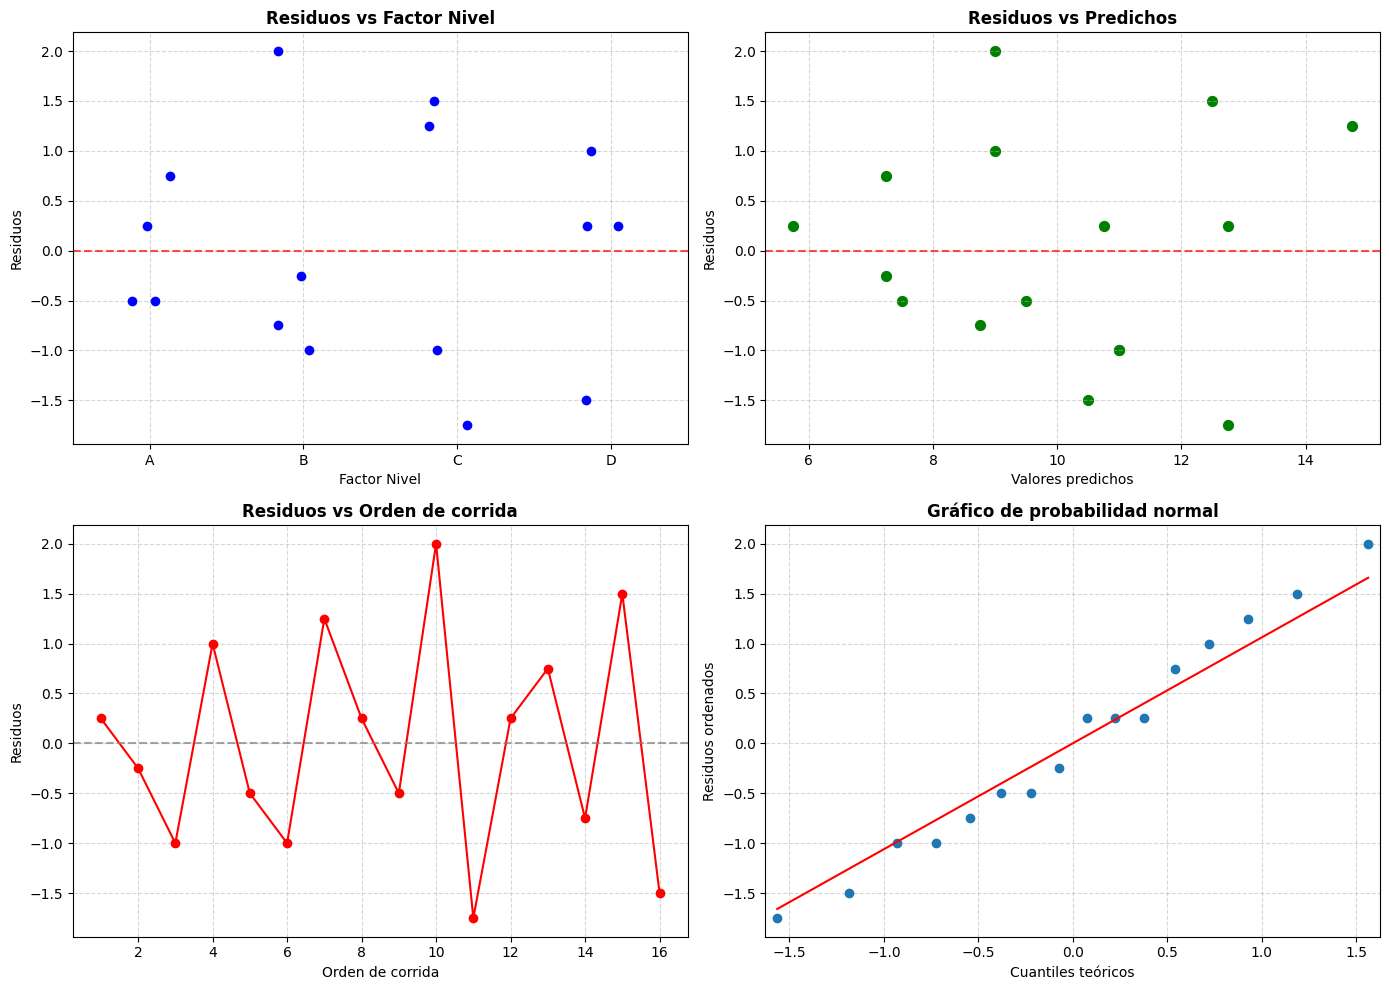

In [ ]:
# 2. Ajuste del modelo ANOVA (DBCA)
modelo = ols('Tiempo ~ C(Metodo) + C(Operador)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=2)

print("--- TABLA ANOVA ---")
print(tabla_anova)
print("\n" + "="*50 + "\n")

# 3. Prueba HSD de Tukey (alfa = 0.05)
tukey = pairwise_tukeyhsd(endog=df['Tiempo'], groups=df['Metodo'], alpha=0.05)
print("--- 2. PRUEBA HSD DE TUKEY ---")
print(tukey)
print("\n" + "="*50 + "\n")

# 4. Cálculo de valores predichos, residuos y orden de corrida
df['Predichos'] = modelo.fittedvalues
df['Residuos'] = modelo.resid
df['Orden'] = range(1, len(df) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5.1 Residuos vs Factor Nivel
sns.stripplot(data=df, x='Metodo', y='Residuos', ax=axes[0, 0], color='blue', jitter=0.2, size=7)
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.7)
axes[0, 0].set_title('Residuos vs Factor Nivel', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Factor Nivel')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# 5.2 Residuos vs Predichos
axes[0, 1].scatter(df['Predichos'], df['Residuos'], color='green', s=50)
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.7)
axes[0, 1].set_title('Residuos vs Predichos', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Valores predichos')
axes[0, 1].set_ylabel('Residuos')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# 5.3 Residuos vs Orden de corrida
axes[1, 0].plot(df['Orden'], df['Residuos'], marker='o', color='red', linestyle='-')
axes[1, 0].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1, 0].set_title('Residuos vs Orden de corrida', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Orden de corrida')
axes[1, 0].set_ylabel('Residuos')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# 5.4 Gráfico de probabilidad normal (Q-Q Plot)
sm.qqplot(df['Residuos'], line='s', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Gráfico de probabilidad normal', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Cuantiles teóricos')
axes[1, 1].set_ylabel('Residuos ordenados')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()